# Stage 0b: Gender Inference via Fine-Tuned Transformer

**Approach:** Instead of explicit self-disclosure patterns (Notebook 00), we **infer** author gender (male / female) from post content using a fine-tuned DistilRoBERTa classifier.

**Training signal:** The 16,056 male/female posts from disclosed+propagated gender labels serve as ground truth. The model learns gendered writing-style features (not explicit mentions like "I'm a 25F") and generalises to **all 47,237 posts**.

| Step | Detail |
|---|---|
| Backbone | `distilroberta-base` (82 M params — CPU-feasible) |
| Training data | 16,056 posts with disclosed/propagated gender (male / female only) |
| Validation | 20 % stratified hold-out |
| Prediction | All 47,237 posts → `gender_inferred` (male / female) + confidence |
| Output | Same LIWC-ready CSV format as Notebook 00 |

In [1]:
import os, warnings, re
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix)
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}  |  GPUs: {N_GPUS}")

print(f"Model: distilroberta-base (82 M params)")

PyTorch 2.6.0+cu124  |  Device: cuda  |  GPUs: 4
Model: distilroberta-base (82 M params)


In [17]:
# ── Load all 47K posts (same pipeline as 00_gender_annotation) ────────────────
cssrs   = pd.read_csv('data/standardized/cssrs_standardized.csv')
mindset = pd.read_csv('data/standardized/mindset_standardized.csv')
umd     = pd.read_csv('data/standardized/umd_standardized.csv')

cssrs['dataset']   = 'cssrs'
mindset['dataset'] = 'mindset'
umd['dataset']     = 'umd'

df = pd.concat([cssrs, mindset, umd], ignore_index=True)
df['text'] = df['sentence'].fillna('')

# Fix CSSRS list-format posts: "['post1', 'post2', ...]" → joined text
list_mask = df['text'].str.startswith("[\'")
if list_mask.any():
    def clean_list_text(s):
        inner = s[2:-2]
        parts = inner.split("', '")
        return ' '.join(parts)
    df.loc[list_mask, 'text'] = df.loc[list_mask, 'text'].apply(clean_list_text)
    print(f"Fixed {list_mask.sum()} CSSRS list-format posts")

df['binary_label'] = df['label'].apply(
    lambda x: 1 if x in ['suicidal', 'at_risk', 'has_condition'] else 0)

print(f"Total posts: {len(df):,}")
print(f"Datasets: {df['dataset'].value_counts().to_dict()}")

Fixed 28 CSSRS list-format posts
Total posts: 47,237
Datasets: {'umd': 21264, 'mindset': 19200, 'cssrs': 6773}


In [24]:
umd

,sentence_id,user_id,sentence,conditions,label,dataset
0,1a2amm,22941,i want to get in to competitive pokémon playin...,['d'],at_risk,umd
1,1axicl,22941,"just wondering, is it safe for me to use Omegl...",['d'],at_risk,umd
2,1bwafu,22941,"I'm still afraid of the dark, help. I have bee...",['d'],at_risk,umd
3,1ddl6m,22941,my place in the world/universe...is it true wh...,['d'],at_risk,umd
4,1dpf5c,22941,I've been trying to LD for a long time For the...,['d'],at_risk,umd
...,...,...,...,...,...,...
21259,3g4nsj,-39465,"[22M4F] Doctors Office RP Hey, I have a doctor...",[nan],no_risk,umd
21260,3hg0b1,-39465,"22M4A looking to play whatever, pm me!",[nan],no_risk,umd
21261,2dfbs3,-39962,Any auto-electricians who can give me a heads ...,[nan],no_risk,umd
21262,2h5nwl,-39962,"[1] 2044 First two pretty easy, third a little...",[nan],no_risk,umd


In [16]:
# ── Load disclosed gender labels & prepare training data ──────────────────────
gender_df = pd.read_pickle('data/gender-annotated/gender_annotated.pkl')

# Use propagated gender (user-level, resolved conflicts) — male/female only
labelled = gender_df[gender_df['propagated_gender'].isin(['male', 'female'])].copy()
labelled['gender_label'] = (labelled['propagated_gender'] == 'female').astype(int)  # 0=male, 1=female

print(f"Labelled posts (male/female): {len(labelled):,}")
print(f"  male:   {(labelled['gender_label']==0).sum():,}")
print(f"  female: {(labelled['gender_label']==1).sum():,}")
print(f"  class ratio: {labelled['gender_label'].mean():.3f} female")

# ── Stratified 80/20 split (user-level: no data leakage across splits) ───────
# Split by user_id so all posts from one user stay in the same split
user_labels = labelled.groupby('user_id')['gender_label'].first()
train_users, val_users = train_test_split(
    user_labels.index, test_size=0.2, stratify=user_labels.values, random_state=42)

train_df = labelled[labelled['user_id'].isin(train_users)].copy()
val_df   = labelled[labelled['user_id'].isin(val_users)].copy()

print(f"\nTrain: {len(train_df):,} posts from {len(train_users):,} users")
print(f"Val:   {len(val_df):,} posts from {len(val_users):,} users")
print(f"\nTrain label dist: {train_df['gender_label'].value_counts().to_dict()}")
print(f"Val   label dist: {val_df['gender_label'].value_counts().to_dict()}")

Labelled posts (male/female): 16,056
  male:   12,077
  female: 3,979
  class ratio: 0.248 female

Train: 13,591 posts from 386 users
Val:   2,465 posts from 97 users

Train label dist: {0: 10144, 1: 3447}
Val   label dist: {0: 1933, 1: 532}


In [ ]:
# ── Tokenize & create HuggingFace Datasets ────────────────────────────────────
MODEL_NAME = 'distilroberta-base'
MAX_LEN    = 256   # covers 95 %+ of posts; truncates gracefully

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_dataset(frame):
    ds = Dataset.from_dict({
        'text':  frame['text'].tolist(),
        'label': frame['gender_label'].tolist(),
    })
    ds = ds.map(
        lambda ex: tokenizer(ex['text'], truncation=True, padding='max_length',
                             max_length=MAX_LEN),
        batched=True, batch_size=512, desc='Tokenizing')
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    return ds

train_ds = make_dataset(train_df)

val_ds   = make_dataset(val_df)

print(f"Train dataset: {len(train_ds):,} samples")
print(f"Val   dataset: {len(val_ds):,} samples")
print(f"Token example: {tokenizer.decode(train_ds[0]['input_ids'][:30], skip_special_tokens=True)[:80]}…")

Tokenizing: 100%|██████████| 2465/2465 [00:02<00:00, 1036.32 examples/s]

Train dataset: 13,591 samples
Val   dataset: 2,465 samples
Token example: Hi NEM3030. What sorts of things do you enjoy doing?…


In [15]:
train_df['label'].value_counts()
train_df['propagated_gender'].value_counts()


propagated_gender
male      10144
female     3447
Name: count, dtype: int64

In [ ]:
# ── Fine-tune DistilRoBERTa  (multi-GPU: 4× V100-16 GB) ──────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: 'male', 1: 'female'},
    label2id={'male': 0, 'female': 1},
)

# Class weights to handle imbalance (≈75 % male, ≈25 % female)
n_male   = (train_df['gender_label'] == 0).sum()
n_female = (train_df['gender_label'] == 1).sum()
weight_male   = len(train_df) / (2 * n_male)
weight_female = len(train_df) / (2 * n_female)
class_weights = torch.tensor([weight_male, weight_female], dtype=torch.float32)
print(f"Class weights: male={weight_male:.3f}, female={weight_female:.3f}")

class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

class BalancedTrainer(Trainer):
    """Trainer that oversamples the minority class each epoch."""
    def get_train_dataloader(self):
        # Create a balanced sampler for the training dataset
        labels = self.train_dataset['label']
        class_counts = np.bincount(labels)
        class_weights = 1. / class_counts
        sample_weights = class_weights[labels]
        sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))
        return torch.utils.data.DataLoader(
            self.train_dataset, batch_size=self.args.per_device_train_batch_size,
            sampler=sampler, num_workers=self.args.dataloader_num_workers)
    
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    probs  = torch.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_female': f1_score(labels, preds, pos_label=1),
        'auc': roc_auc_score(labels, probs),
    }

# ── Training arguments — optimised for 4× V100-16GB ──────────────────────────
# Effective batch = per_device_train_batch_size × N_GPUS = 64 × 4 = 256
training_args = TrainingArguments(
    output_dir='models/gender_distilroberta',
    num_train_epochs=5,
    per_device_train_batch_size=64,          # 64 per GPU × 4 GPUs = 256 effective
    per_device_eval_batch_size=128,          # larger eval batch (no grads)
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,                               # V100 has excellent FP16 perf
    dataloader_num_workers=4,                # parallel data loading
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    save_total_limit=2,
    seed=42,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

eff_batch = training_args.per_device_train_batch_size * max(N_GPUS, 1)
print(f"Training on {N_GPUS}× GPU  |  {len(train_ds):,} train, {len(val_ds):,} val")
print(f"Epochs: {int(training_args.num_train_epochs)}  |  Batch/GPU: {training_args.per_device_train_batch_size}  |  Effective: {eff_batch}")
print(f"FP16: {training_args.fp16}  |  Workers: {training_args.dataloader_num_workers}")
print("Starting training …\n")
trainer.train()

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 4113.42it/s]
RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be re

Class weights: male=0.670, female=1.971
Training on 4× GPU  |  13,591 train, 2,465 val
Epochs: 5  |  Batch/GPU: 64  |  Effective: 256
FP16: True  |  Workers: 4
Starting training …



ValueError: The model did not return a loss from the inputs, only the following keys: logits. For reference, the inputs it received are label,input_ids,attention_mask.

VALIDATION SET RESULTS

Accuracy:  0.7404
F1 (macro): 0.6620
F1 (female): 0.4992
AUC:        0.7592

              precision    recall  f1-score   support

        male       0.88      0.78      0.82      1933
      female       0.43      0.60      0.50       532

    accuracy                           0.74      2465
   macro avg       0.65      0.69      0.66      2465
weighted avg       0.78      0.74      0.75      2465



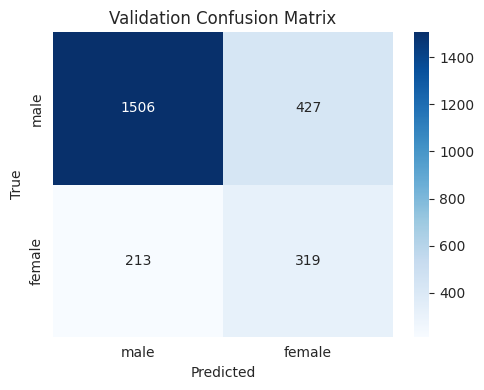

In [6]:
# ── Detailed evaluation on held-out validation set ────────────────────────────
val_pred = trainer.predict(val_ds)
y_true = val_pred.label_ids
y_pred = val_pred.predictions.argmax(-1)
y_prob = torch.softmax(torch.tensor(val_pred.predictions), dim=-1)[:, 1].numpy()

print("=" * 60)
print("VALIDATION SET RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1 (female): {f1_score(y_true, y_pred, pos_label=1):.4f}")
print(f"AUC:        {roc_auc_score(y_true, y_prob):.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['male', 'female'])}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['male', 'female'], yticklabels=['male', 'female'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Validation Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
# ── Predict gender for ALL 47,237 posts ───────────────────────────────────────
print(f"Predicting gender for all {len(df):,} posts …")

all_ds = Dataset.from_dict({'text': df['text'].tolist(), 'label': [0] * len(df)})
all_ds = all_ds.map(
    lambda ex: tokenizer(ex['text'], truncation=True, padding='max_length',
                         max_length=MAX_LEN),
    batched=True, batch_size=512, desc='Tokenizing all')
all_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

all_pred = trainer.predict(all_ds)
all_probs = torch.softmax(torch.tensor(all_pred.predictions), dim=-1).numpy()
all_labels = all_pred.predictions.argmax(-1)

df['gender_inferred'] = np.where(all_labels == 0, 'male', 'female')
df['gender_confidence'] = np.max(all_probs, axis=1)
df['gender_prob_female'] = all_probs[:, 1]

print(f"\nInferred gender distribution:")
print(df['gender_inferred'].value_counts().to_string())
print(f"\nMean confidence: {df['gender_confidence'].mean():.4f}")
print(f"High-confidence (≥0.80): {(df['gender_confidence'] >= 0.80).sum():,} ({(df['gender_confidence'] >= 0.80).mean()*100:.1f}%)")
print(f"High-confidence (≥0.90): {(df['gender_confidence'] >= 0.90).sum():,} ({(df['gender_confidence'] >= 0.90).mean()*100:.1f}%)")

Predicting gender for all 47,237 posts …


Tokenizing all: 100%|██████████| 47237/47237 [00:15<00:00, 3102.08 examples/s]



Inferred gender distribution:
gender_inferred
female    23645
male      23592

Mean confidence: 0.6282
High-confidence (≥0.80): 1,286 (2.7%)
High-confidence (≥0.90): 0 (0.0%)


In [ ]:
# ── Validate inferred vs disclosed gender ─────────────────────────────────────
# Merge inferred predictions back against the disclosed ground truth
eval_merge = df[['text', 'gender_inferred', 'gender_confidence']].copy()
eval_merge['idx'] = range(len(eval_merge))

# Get disclosed labels from gender_annotated.pkl
disclosed = gender_df[gender_df['propagated_gender'].isin(['male', 'female'])].copy()
disclosed['disclosed_gender'] = disclosed['propagated_gender']
disclosed['idx'] = disclosed.index  # original index matches df

# Only compare for rows with disclosed gender
comparison = eval_merge.merge(
    disclosed[['idx', 'disclosed_gender']], on='idx', how='inner')

comparison['match'] = comparison['gender_inferred'] == comparison['disclosed_gender']

print("=" * 60)
print("INFERRED vs DISCLOSED GENDER AGREEMENT")
print("=" * 60)
print(f"Posts with disclosed gender: {len(comparison):,}")
print(f"Agreement: {comparison['match'].mean():.4f} ({comparison['match'].sum():,} / {len(comparison):,})")

# Breakdown by confidence band
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
    sub = comparison[comparison['gender_confidence'] >= thresh]
    if len(sub) > 0:
        print(f"  conf ≥ {thresh}: {sub['match'].mean():.4f}  ({len(sub):,} posts)")

# Per-dataset agreement
print(f"\nPer-dataset agreement:")
comp_with_ds = comparison.merge(df[['dataset']].reset_index().rename(columns={'index': 'idx'}), on='idx')
for ds in ['cssrs', 'mindset', 'umd']:
    sub = comp_with_ds[comp_with_ds['dataset'] == ds]
    if len(sub) > 0:
        print(f"  {ds}: {sub['match'].mean():.4f}  ({len(sub):,} posts)")

# Cross-tab
print(f"\nCross-tabulation (disclosed × inferred):")
print(pd.crosstab(comparison['disclosed_gender'], comparison['gender_inferred'], margins=True))

In [ ]:
# ── Visualisation: distributions & confidence ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Inferred gender by dataset
ct = pd.crosstab(df['dataset'], df['gender_inferred'], normalize='index') * 100
ct.plot.bar(ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_ylabel('Percentage')
axes[0].set_title('Inferred Gender by Dataset')
axes[0].legend(title='Gender')
axes[0].tick_params(axis='x', rotation=0)

# (B) Confidence distribution
axes[1].hist(df['gender_confidence'], bins=50, color='#2c3e50', edgecolor='white', alpha=0.8)
axes[1].axvline(0.8, color='red', linestyle='--', label='0.80 threshold')
axes[1].axvline(0.9, color='orange', linestyle='--', label='0.90 threshold')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution (all 47K posts)')
axes[1].legend()

# (C) Inferred gender by label
ct2 = pd.crosstab(df['binary_label'].map({0: 'negative', 1: 'positive'}),
                   df['gender_inferred'], normalize='index') * 100
ct2.plot.bar(ax=axes[2], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[2].set_ylabel('Percentage')
axes[2].set_title('Inferred Gender by Mental-Health Label')
axes[2].legend(title='Gender')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('data/gender_inference_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/gender_inference_distributions.png")

In [ ]:
# ================================================================
# EXPORT LIWC-READY CSV — ALL 47,237 posts with inferred gender
# ================================================================
# Same format as 00_gender_annotation output for downstream compatibility.

liwc_df = df.copy().reset_index(drop=True)
liwc_df.insert(0, 'row_id', range(1, len(liwc_df) + 1))

# Keep columns compatible with the disclosure-based output
liwc_df = liwc_df[['row_id', 'sentence_id', 'user_id', 'text', 'dataset',
                    'label', 'binary_label',
                    'gender_inferred', 'gender_confidence', 'gender_prob_female']]

# Rename for downstream consistency
liwc_df = liwc_df.rename(columns={'gender_inferred': 'gender_label'})

# Verify text quality
bad = liwc_df['text'].str.startswith("[\'")
empty = (liwc_df['text'].isna() | (liwc_df['text'] == ''))
print(f"✓ List-format rows: {bad.sum()}")
print(f"✓ Empty text rows: {empty.sum()}")

out_path = 'data/gender-inferred/all_gender_inferred_for_liwc.csv'
os.makedirs('data/gender-inferred', exist_ok=True)
liwc_df.to_csv(out_path, index=False)

print(f"\nRows: {len(liwc_df):,}")
print(f"Columns: {list(liwc_df.columns)}")
print(f"\nGender breakdown:\n{liwc_df['gender_label'].value_counts().to_string()}")
print(f"\nDataset breakdown:\n{liwc_df['dataset'].value_counts().to_string()}")
print(f"\nLabel breakdown:\n{liwc_df['binary_label'].value_counts().to_string()}")
print(f"\nSaved → {out_path}")

# Also save the model for reproducibility
model_save_path = 'models/gender_distilroberta/best'
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model saved → {model_save_path}/")